**PLOTING ALL THE NUTRIENT VALUES COMAPRISION with RDA**

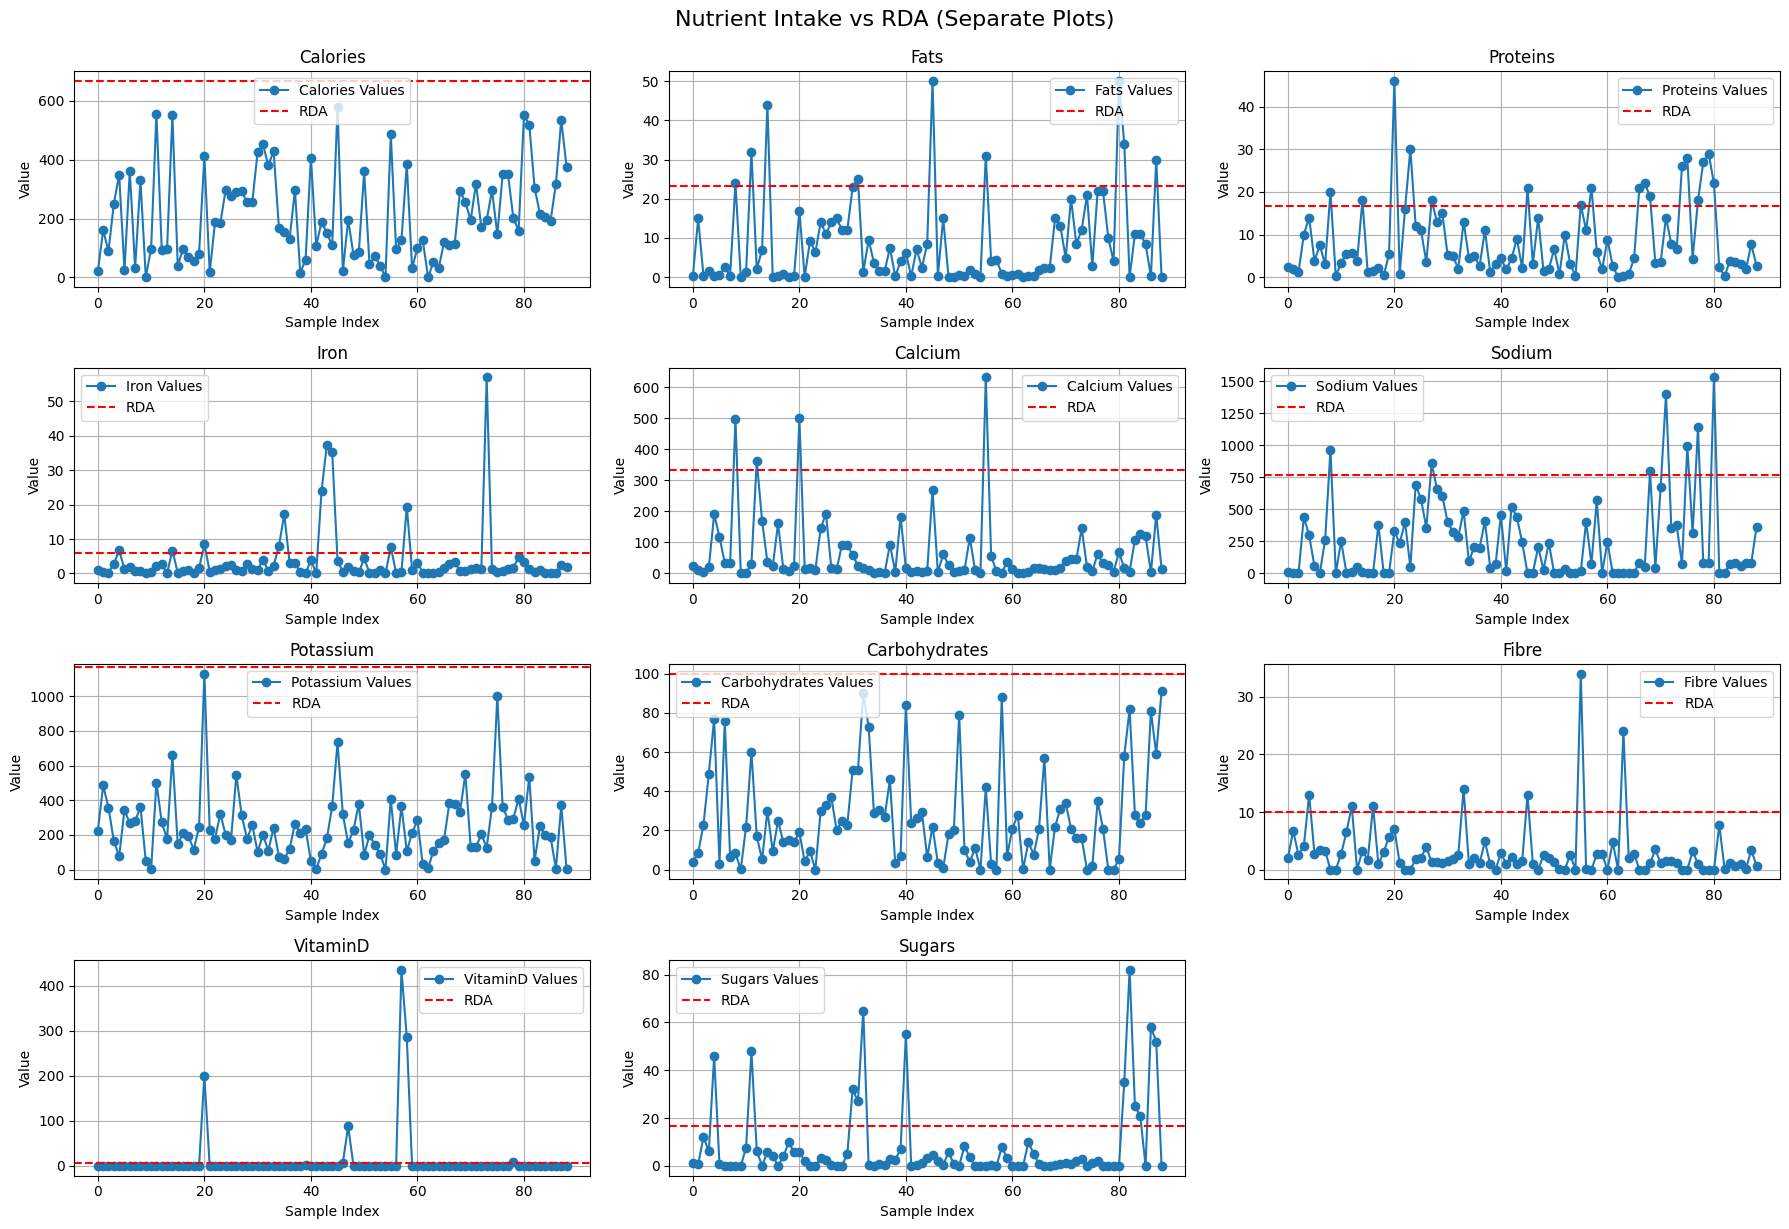


Samples flagged as outliers in more than 10 nutrients:
[0, 1, 3, 5, 7, 9, 10, 13, 15, 17, 18, 19, 21, 23, 26, 34, 35, 36, 37, 38, 39, 41, 42, 43, 44, 48, 49, 51, 52, 53, 54, 56, 59, 60, 61, 62, 63, 64, 65, 67, 69, 72, 73, 83, 85]


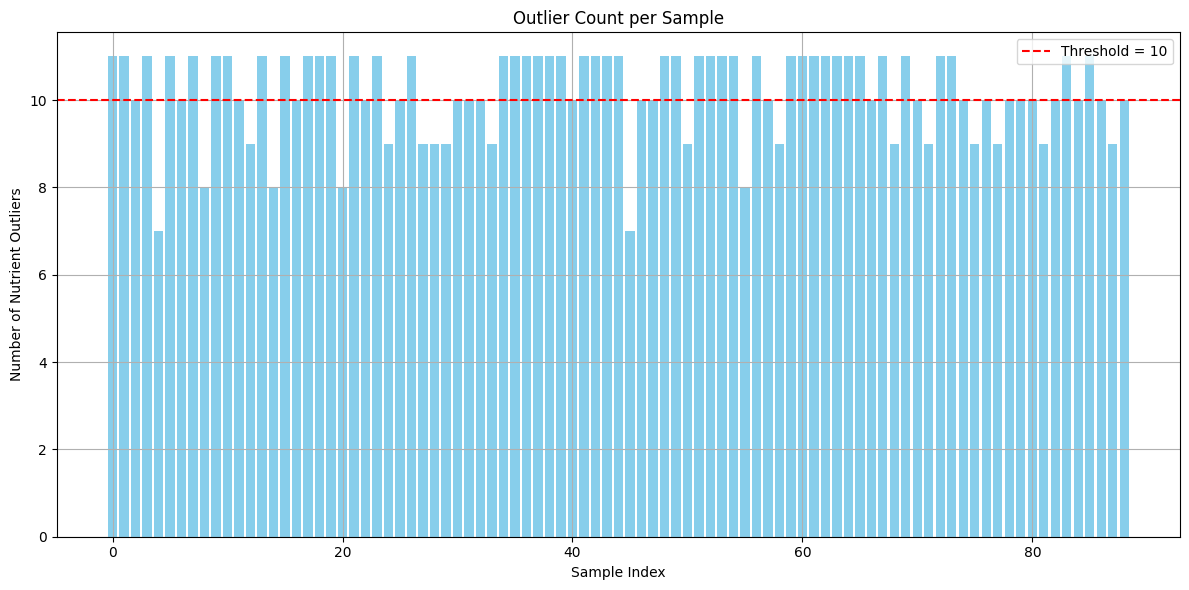

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("indian_rda_based_diet_recommendation_system.csv")

# Desired daily intake values
daily_requirements = {
    'Calories': 2000/3,
    'Fats': 70/3,
    'Proteins': 50/3,
    'Iron': 18/3,
    'Calcium': 1000/3,
    'Sodium': 2300/3,
    'Potassium': 3500/3,
    'Carbohydrates': 300/3,
    'Fibre': 30/3,
    'VitaminD': 20/3,
    'Sugars': 50/3,
}

# Create subplots
num_nutrients = len(daily_requirements)
cols = 3
rows = (num_nutrients + cols - 1) // cols  # round up
fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
axes = axes.flatten()

# Outlier detection storage
outlier_flags = pd.DataFrame(0, index=df.index, columns=daily_requirements.keys())

# Plot each nutrient in its own subplot
for i, (nutrient, rda_value) in enumerate(daily_requirements.items()):
    values = df[nutrient]
    x = list(range(len(values)))

    # Outlier threshold: ±30% of RDA
    lower_bound = rda_value * 0.7
    upper_bound = rda_value * 1.3

    # Flag outliers
    outlier_flags[nutrient] = (values < lower_bound) | (values > upper_bound)

    # Plot
    ax = axes[i]
    ax.plot(x, values, marker='o', label=f'{nutrient} Values')
    ax.axhline(y=rda_value, color='r', linestyle='--', label='RDA')
    ax.set_title(nutrient)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Value')
    ax.grid(True)
    ax.legend()

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Nutrient Intake vs RDA (Separate Plots)', fontsize=16, y=1.02)
plt.show()

# Count how many nutrients each sample is an outlier in
outlier_counts = outlier_flags.sum(axis=1)

# Identify samples that are outliers across all nutrients (or a threshold, e.g., >5 nutrients)
threshold = 10
common_outliers = outlier_counts[outlier_counts > threshold].index.tolist()

print("\nSamples flagged as outliers in more than", threshold, "nutrients:")
print(common_outliers)


# Plot outlier count per sample
plt.figure(figsize=(12, 6))
plt.bar(outlier_counts.index, outlier_counts.values, color='skyblue')
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
plt.title('Outlier Count per Sample')
plt.xlabel('Sample Index')
plt.ylabel('Number of Nutrient Outliers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**OUTLIER DETECTION usign LOF for each nutrient**

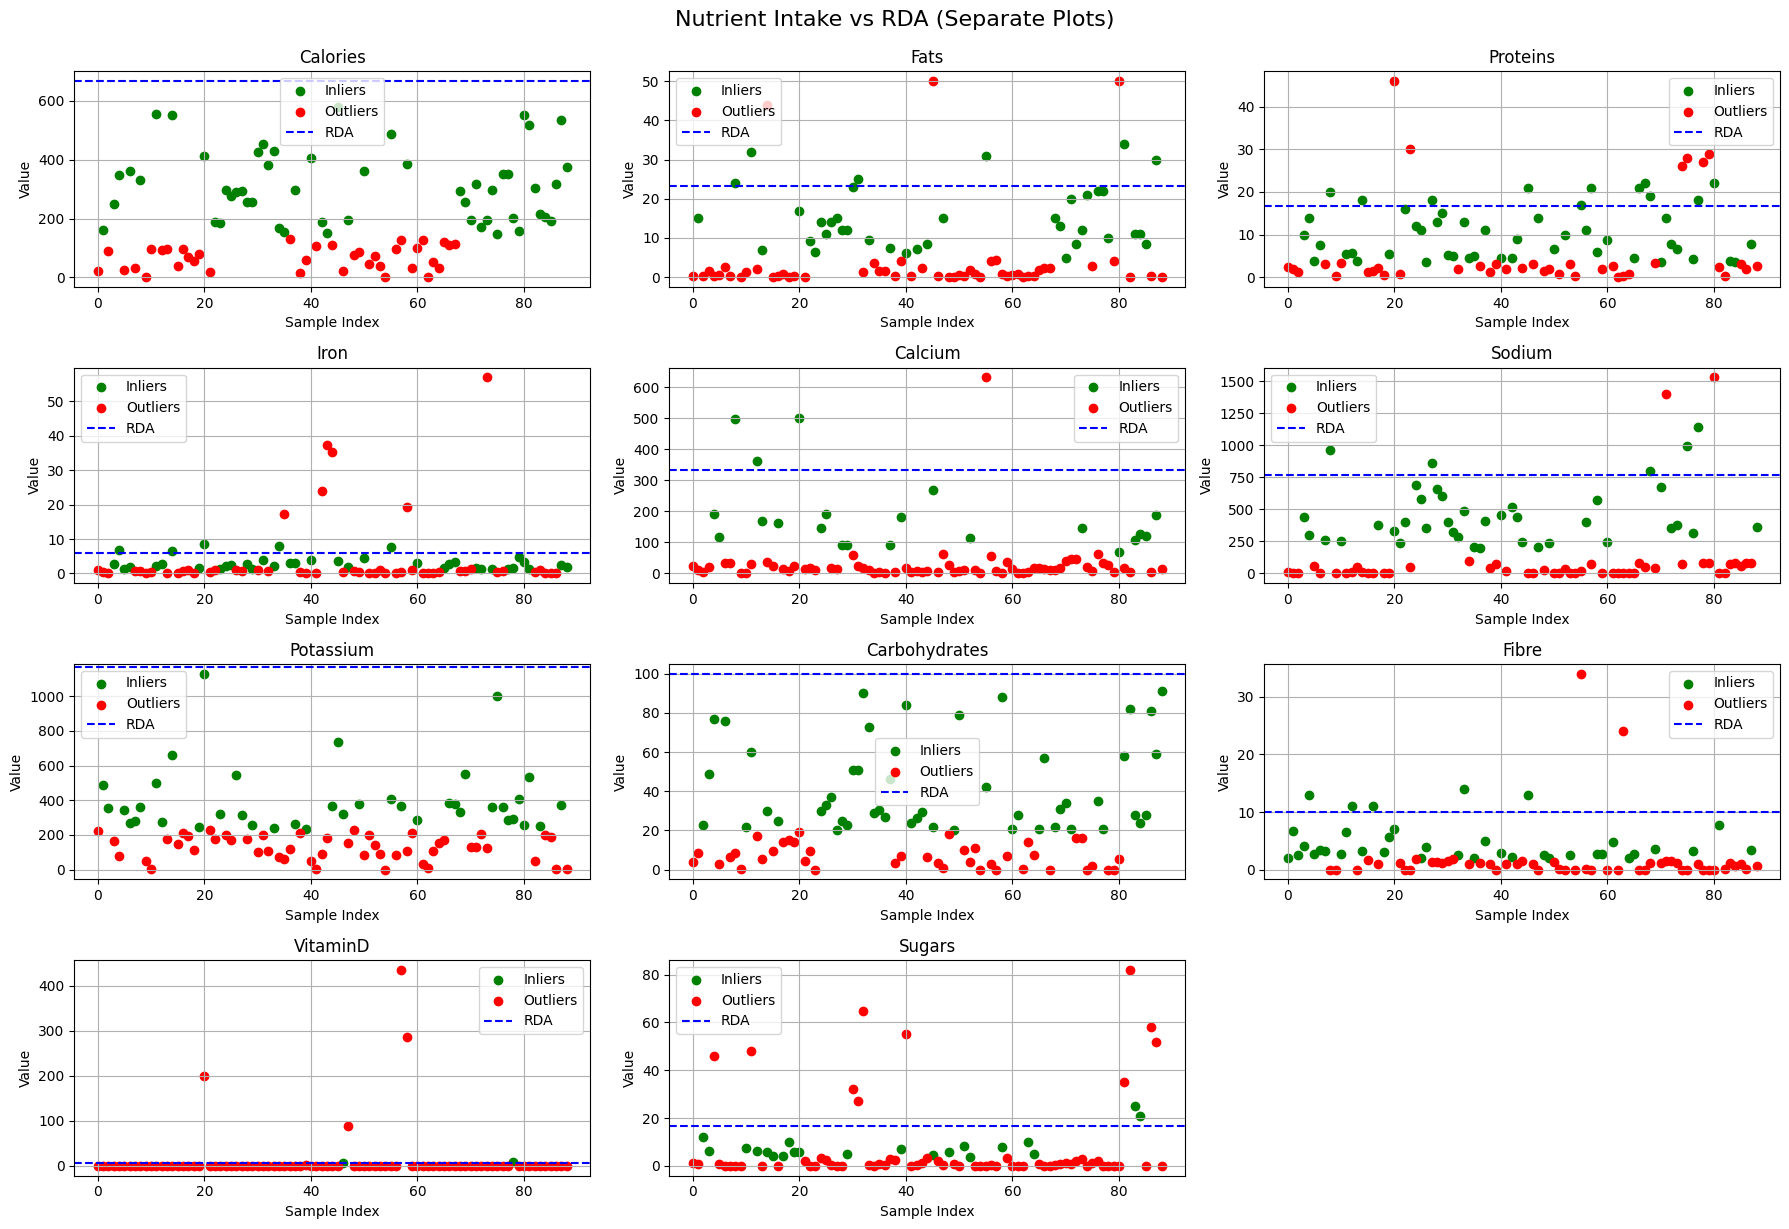


Samples flagged as outliers in more than 11 nutrients:
[]


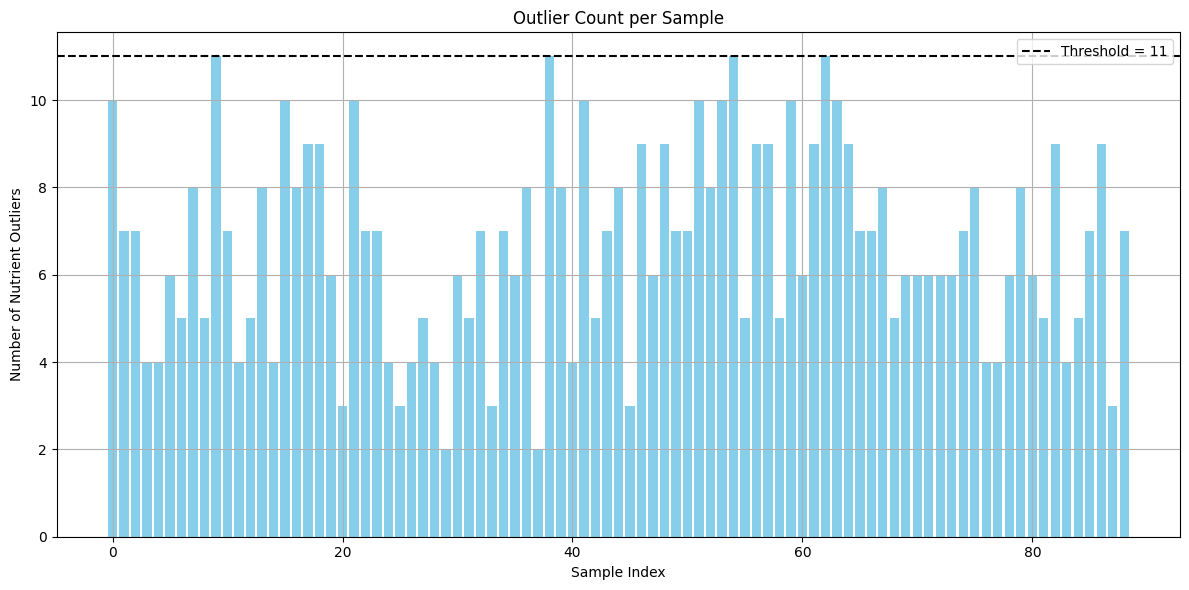

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("indian_rda_based_diet_recommendation_system.csv")

# Desired daily intake values
daily_requirements = {
    'Calories': 2000/3,
    'Fats': 70/3,
    'Proteins': 50/3,
    'Iron': 18/3,
    'Calcium': 1000/3,
    'Sodium': 2300/3,
    'Potassium': 3500/3,
    'Carbohydrates': 300/3,
    'Fibre': 30/3,
    'VitaminD': 20/3,
    'Sugars': 50/3,
}

# Create subplots
num_nutrients = len(daily_requirements)
cols = 3
rows = (num_nutrients + cols - 1) // cols  # round up
fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
axes = axes.flatten()

# Outlier detection storage
outlier_flags = pd.DataFrame(0, index=df.index, columns=daily_requirements.keys())

# Plot each nutrient in its own subplot
for i, (nutrient, rda_value) in enumerate(daily_requirements.items()):
    values = df[nutrient]
    x = list(range(len(values)))

    # Outlier threshold: ±30% of RDA
    lower_bound = rda_value * 0.2
    upper_bound = rda_value * 1.5

    # Flag outliers
    is_outlier = (values < lower_bound) | (values > upper_bound)
    outlier_flags[nutrient] = is_outlier

    # Separate values
    inlier_x = [idx for idx in x if not is_outlier[idx]]
    inlier_y = [values[idx] for idx in inlier_x]
    outlier_x = [idx for idx in x if is_outlier[idx]]
    outlier_y = [values[idx] for idx in outlier_x]

    # Plot
    ax = axes[i]
    ax.scatter(inlier_x, inlier_y, color='green', label='Inliers')
    ax.scatter(outlier_x, outlier_y, color='red', label='Outliers')
    ax.axhline(y=rda_value, color='blue', linestyle='--', label='RDA')
    ax.set_title(nutrient)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Value')
    ax.grid(True)
    ax.legend()

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Nutrient Intake vs RDA (Separate Plots)', fontsize=16, y=1.02)
plt.show()

# Count how many nutrients each sample is an outlier in
outlier_counts = outlier_flags.sum(axis=1)

# Identify samples that are outliers across all nutrients (or a threshold, e.g., >5 nutrients)
threshold = 11
common_outliers = outlier_counts[outlier_counts > threshold].index.tolist()

print("\nSamples flagged as outliers in more than", threshold, "nutrients:")
print(common_outliers)

# Plot outlier count per sample with color highlighting
colors = ['red' if count > threshold else 'skyblue' for count in outlier_counts.values]

plt.figure(figsize=(12, 6))
plt.bar(outlier_counts.index, outlier_counts.values, color=colors)
plt.axhline(y=threshold, color='black', linestyle='--', label=f'Threshold = {threshold}')
plt.title('Outlier Count per Sample')
plt.xlabel('Sample Index')
plt.ylabel('Number of Nutrient Outliers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


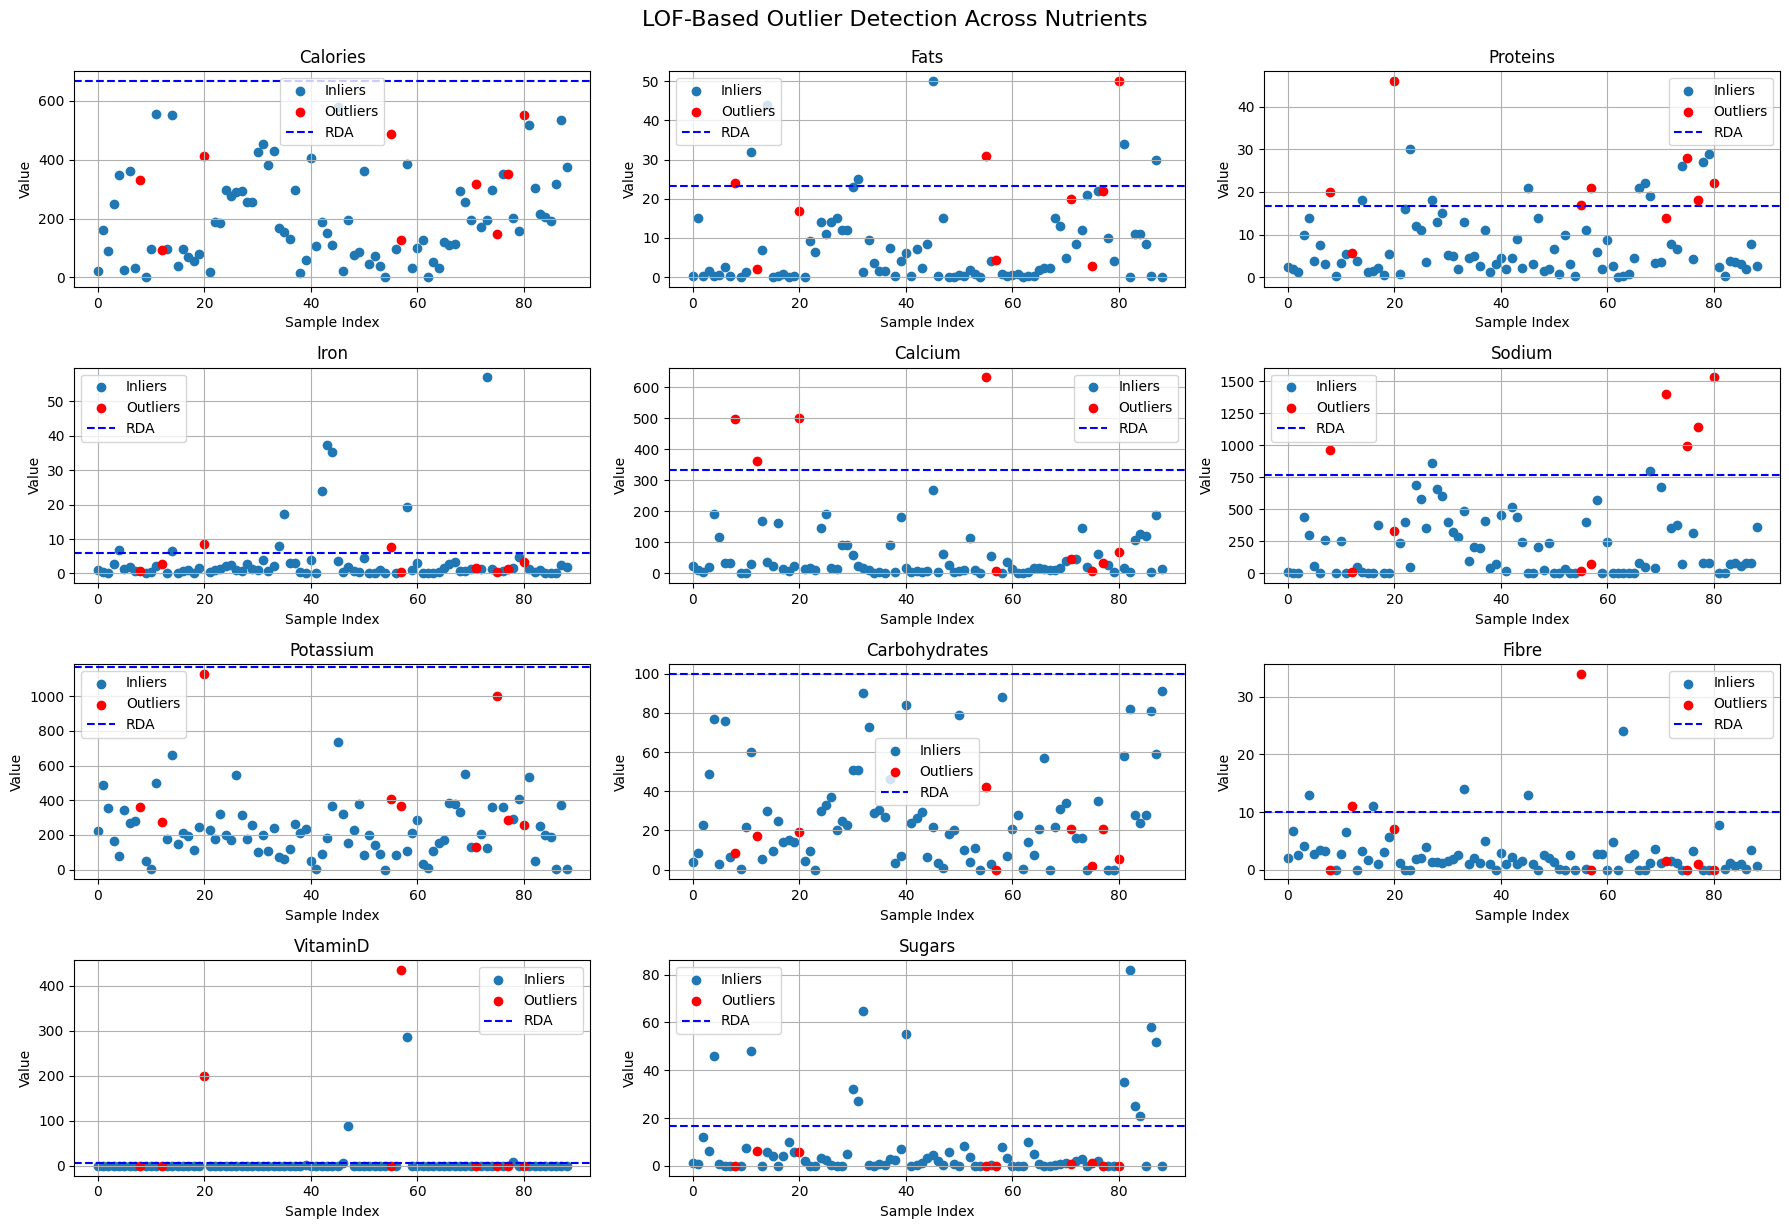

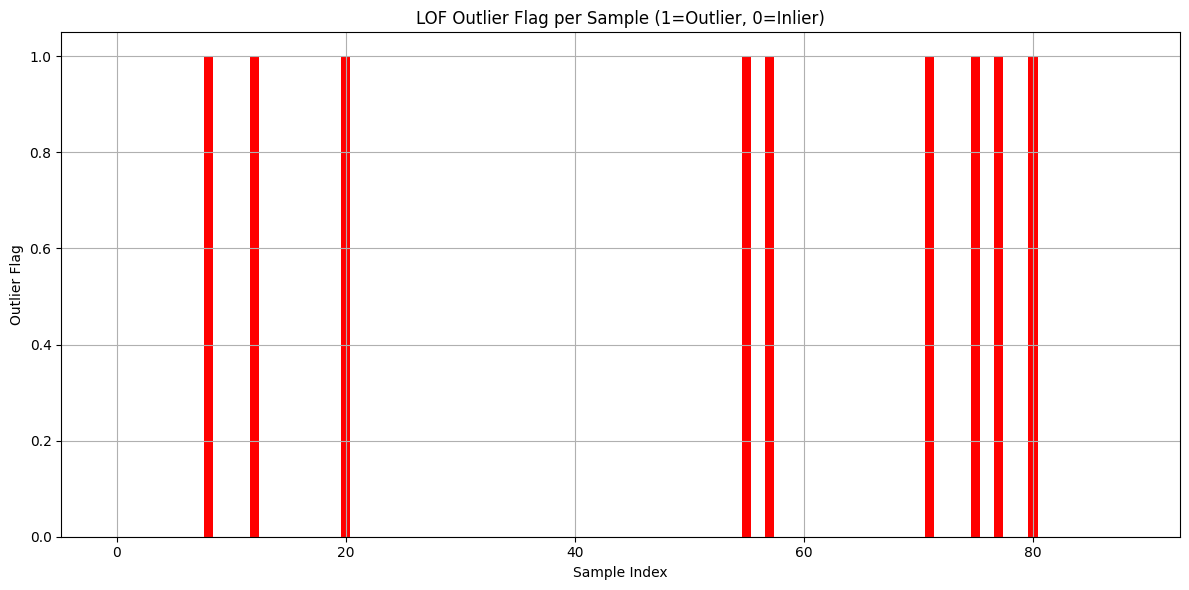

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# Load dataset
df = pd.read_csv("indian_rda_based_diet_recommendation_system.csv")

# Desired daily intake values
daily_requirements = {
    'Calories': 2000/3,
    'Fats': 70/3,
    'Proteins': 50/3,
    'Iron': 18/3,
    'Calcium': 1000/3,
    'Sodium': 2300/3,
    'Potassium': 3500/3,
    'Carbohydrates': 300/3,
    'Fibre': 30/3,
    'VitaminD': 20/3,
    'Sugars': 50/3,
}

# Prepare nutrient data for LOF
nutrient_cols = list(daily_requirements.keys())
df_nutrients = df[nutrient_cols]

# Multivariate outlier detection using Local Outlier Factor
# n_neighbors: number of neighbors to use for LOF\# contamination: expected proportion of outliers
lof = LocalOutlierFactor(n_neighbors=10, contamination=0.1)
lof_pred = lof.fit_predict(df_nutrients)
# True for outliers, False for inliers
outlier_mask = lof_pred == -1

# Plot each nutrient vs RDA, color-coded by LOF
num_nutrients = len(nutrient_cols)
cols = 3
rows = (num_nutrients + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
axes = axes.flatten()

for i, nutrient in enumerate(nutrient_cols):
    values = df[nutrient]
    x = list(range(len(values)))
    ax = axes[i]

    # Split by LOF flags
    inlier_x = [xi for xi, flag in zip(x, outlier_mask) if not flag]
    inlier_y = [val for val, flag in zip(values, outlier_mask) if not flag]
    outlier_x = [xi for xi, flag in zip(x, outlier_mask) if flag]
    outlier_y = [val for val, flag in zip(values, outlier_mask) if flag]

    # Scatter plot
    ax.scatter(inlier_x, inlier_y, label='Inliers')
    ax.scatter(outlier_x, outlier_y, color='red', label='Outliers')
    ax.axhline(y=daily_requirements[nutrient], color='blue', linestyle='--', label='RDA')
    ax.set_title(nutrient)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Value')
    ax.grid(True)
    ax.legend()

# Remove extra subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('LOF-Based Outlier Detection Across Nutrients', fontsize=16, y=1.02)
plt.show()

# Plot LOF outlier flag distribution per sample
flags_int = outlier_mask.astype(int)
plt.figure(figsize=(12, 6))
colors = ['red' if flag else 'skyblue' for flag in outlier_mask]
plt.bar(df.index, flags_int, color=colors)
plt.title('LOF Outlier Flag per Sample (1=Outlier, 0=Inlier)')
plt.xlabel('Sample Index')
plt.ylabel('Outlier Flag')
plt.grid(True)
plt.tight_layout()
plt.show()


**Considering mean of the data set**

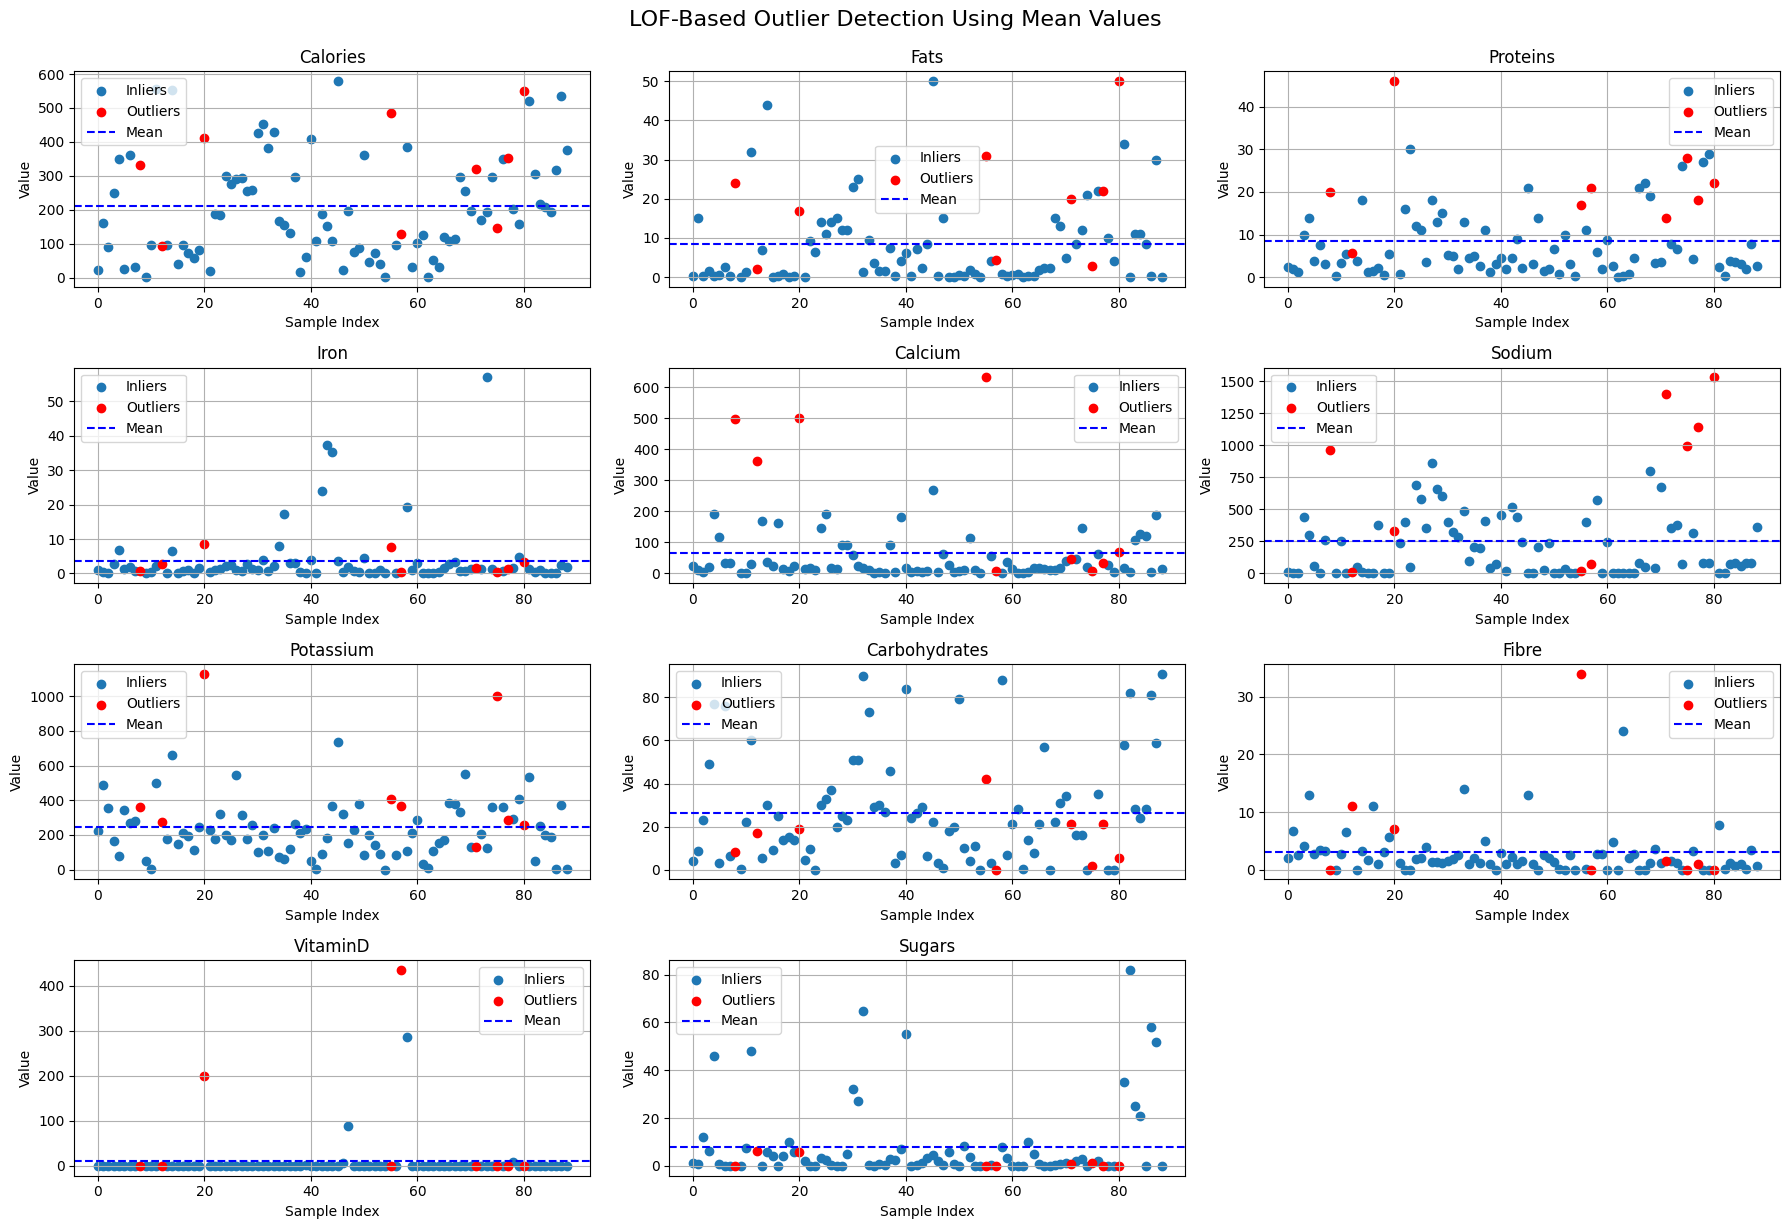

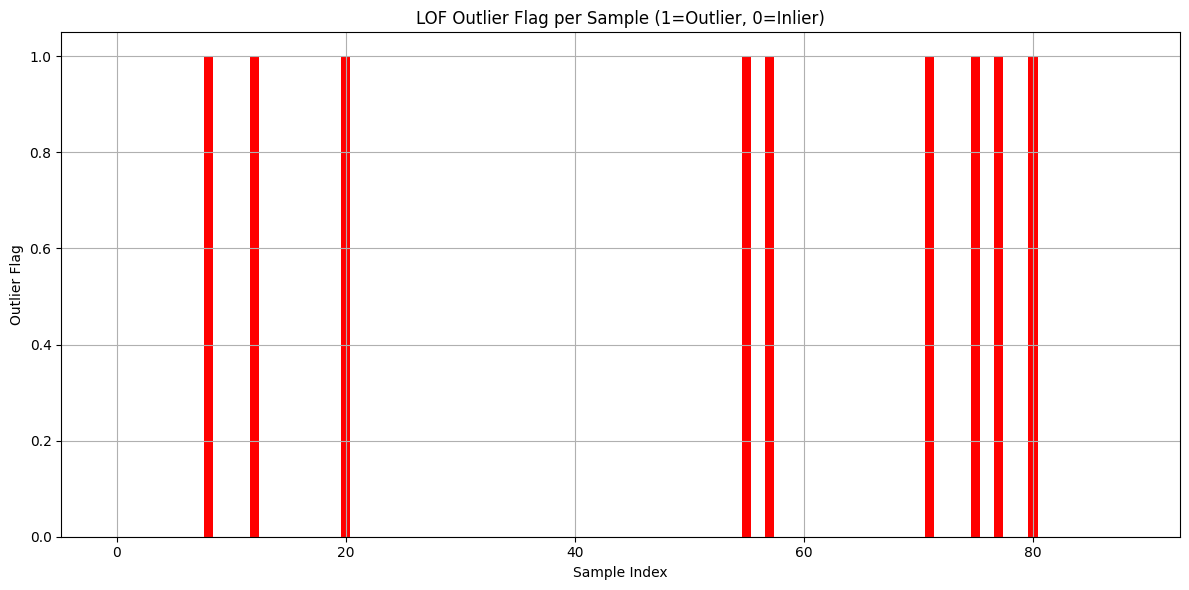

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# Load dataset
df = pd.read_csv("indian_rda_based_diet_recommendation_system.csv")

# Nutrient columns to analyze
nutrient_cols = [
    'Calories', 'Fats', 'Proteins', 'Iron', 'Calcium',
    'Sodium', 'Potassium', 'Carbohydrates', 'Fibre',
    'VitaminD', 'Sugars'
]

# Prepare nutrient data for LOF
df_nutrients = df[nutrient_cols]

# Calculate mean nutrient values for reference
mean_nutrients = df_nutrients.mean()

# Multivariate outlier detection using Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=10, contamination=0.1)
lof_pred = lof.fit_predict(df_nutrients)
outlier_mask = lof_pred == -1

# Plot each nutrient vs mean, color-coded by LOF
num_nutrients = len(nutrient_cols)
cols = 3
rows = (num_nutrients + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
axes = axes.flatten()

for i, nutrient in enumerate(nutrient_cols):
    values = df[nutrient]
    x = list(range(len(values)))
    ax = axes[i]

    inlier_x = [xi for xi, flag in zip(x, outlier_mask) if not flag]
    inlier_y = [val for val, flag in zip(values, outlier_mask) if not flag]
    outlier_x = [xi for xi, flag in zip(x, outlier_mask) if flag]
    outlier_y = [val for val, flag in zip(values, outlier_mask) if flag]

    ax.scatter(inlier_x, inlier_y, label='Inliers')
    ax.scatter(outlier_x, outlier_y, color='red', label='Outliers')
    ax.axhline(y=mean_nutrients[nutrient], color='blue', linestyle='--', label='Mean')
    ax.set_title(nutrient)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Value')
    ax.grid(True)
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('LOF-Based Outlier Detection Using Mean Values', fontsize=16, y=1.02)
plt.show()

# Plot LOF outlier flag distribution per sample
flags_int = outlier_mask.astype(int)
plt.figure(figsize=(12, 6))
colors = ['red' if flag else 'skyblue' for flag in outlier_mask]
plt.bar(df.index, flags_int, color=colors)
plt.title('LOF Outlier Flag per Sample (1=Outlier, 0=Inlier)')
plt.xlabel('Sample Index')
plt.ylabel('Outlier Flag')
plt.grid(True)
plt.tight_layout()
plt.show()
